# Análisis Geoespacial IPM - Zona de Estudio: Roosevelt

Este notebook prioriza la visualización cartográfica de las 5 variables más relevantes del Índice de Pobreza Multidimensional (IPM) en el corredor Roosevelt (Buffer 100m).

**Características:**
- Mapa base con delimitación de manzanas.
- Etiquetas de valores dentro de cada manzana.
- Paleta de colores accesible para personas daltónicas (Viridis).
- Leyenda de categorías basada en la incidencia.

In [16]:
# 1. Instalación de dependencias (solo en Colab)
import sys
if 'google.colab' in sys.modules:
    !pip install geopandas matplotlib seaborn -q

In [17]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns
import os

sns.set_style('white')
print('Librerías listas')

Librerías listas


In [18]:
# 2. Clonar o actualizar repositorio (solo Colab)
import sys
REPO_URL = 'https://github.com/j0rg3c45/Pobreza_multidimensional_y_condicion_social.git'
REPO_DIR = 'Pobreza_multidimensional_y_condicion_social'

if 'google.colab' in sys.modules:
    if not os.path.exists(REPO_DIR):
        !git clone {REPO_URL}
    else:
        !cd {REPO_DIR} && git pull
    print('Repositorio listo')

# 3. Carga de datos
PATH_GEOJSON = '../data/Geojson_Roosevelt/geojson_filtrado_tramos_Roosevelt_Buffer_100/Mzn_ipm_variables_filtrado_tramos_Roosevelt_Buffer_100.geojson'

if not os.path.exists(PATH_GEOJSON):
    PATH_GEOJSON = os.path.join(REPO_DIR, 'indice_Pobreza/data/Geojson_Roosevelt/geojson_filtrado_tramos_Roosevelt_Buffer_100/Mzn_ipm_variables_filtrado_tramos_Roosevelt_Buffer_100.geojson')

gdf = gpd.read_file(PATH_GEOJSON)
print(f'Datos cargados: {len(gdf)} manzanas')

remote: Enumerating objects: 9, done.
remote: Counting objects: 100% (9/9), done.
remote: Compressing objects: 100% (1/1), done.
remote: Total 5 (delta 4), reused 5 (delta 4), pack-reused 0 (from 0)
Unpacking objects: 100% (5/5), 1009 bytes | 91.00 KiB/s, done.
From https://github.com/j0rg3c45/Pobreza_multidimensional_y_condicion_social
   98d204f..dcac571  main       -> origin/main
Updating 98d204f..dcac571
Fast-forward
 .../notebooks_py/04_mapeo_ipm_roosevelt.ipynb      | 46 +++++++++++++++-------
 1 file changed, 32 insertions(+), 14 deletions(-)
Repositorio listo
Datos cargados: 40 manzanas


In [19]:
# 3. Identificación de las 15 variables y selección de las Top 5
variables_ipm = [
    'ANALF_', 'BAJO_', 'INFANCIA_', 'INASIS_', 'REZAGO_',
    'TRAB_INFAN', 'DEPEN_', 'INFOR_', 'SALUD_', 'ASEGU_',
    'HACI_', 'PARED_', 'EXCRE_', 'PISOS_', 'AGUA_'
]

# Diccionario para nombres legibles
diccionario_nombres = {
    'ANALF_': 'Analfabetismo', 'BAJO_': 'Bajo Logro Educativo', 'INFANCIA_': 'Barreras Infancia',
    'INASIS_': 'Inasistencia Escolar', 'REZAGO_': 'Rezago Escolar', 'TRAB_INFAN': 'Trabajo Infantil',
    'DEPEN_': 'Dependencia Económica', 'INFOR_': 'Informalidad', 'SALUD_': 'Sin Aseguramiento Salud',
    'ASEGU_': 'Barreras Salud', 'HACI_': 'Hacinamiento Crítico', 'PARED_': 'Paredes Inadecuadas',
    'EXCRE_': 'Excretas Inadecuadas', 'PISOS_': 'Pisos Inadecuados', 'AGUA_': 'Sin Agua Mejorada'
}

# Calcular promedio local para elegir las 5 más relevantes (mayor incidencia)
top_5 = gdf[variables_ipm].mean().sort_values(ascending=False).head(5).index.tolist()
print('Las 5 variables con mayor incidencia en Roosevelt son:')
for v in top_5:
    print(f'- {diccionario_nombres[v]} ({v})')

Las 5 variables con mayor incidencia en Roosevelt son:
- Informalidad (INFOR_)
- Barreras Salud (ASEGU_)
- Dependencia Económica (DEPEN_)
- Bajo Logro Educativo (BAJO_)
- Rezago Escolar (REZAGO_)


In [20]:
# 4. Función de mapeo con escala semántica accesible (daltonismo)
from matplotlib.patheffects import withStroke
from matplotlib.colors import ListedColormap, BoundaryNorm
import matplotlib.patches as mpatches
import matplotlib.cm as cm
import numpy as np

# Escala semántica (8 categorías de intensidad)
CATEGORIAS = [
    'Bajo', 'Moderado-Bajo', 'Moderado', 'Moderado-Alto',
    'Alto', 'Muy Alto', 'Extremo', 'Extremo Máximo'
]

# Paleta accesible para daltonismo: cividis discretizado en 8 niveles
# cividis fue diseñado específicamente para ser perceptualmente uniforme
# y distinguible por personas con deuteranopía y protanopía
_cividis = cm.get_cmap('cividis', 8)
COLORES_ACCESIBLES = [_cividis(i) for i in range(8)]

# Proporciones de corte para escalar al ref_max de cada indicador
# Distribución progresiva: categorías bajas más estrechas, altas más amplias
PROPORCIONES_CORTE = [0.0, 0.06, 0.08, 0.10, 0.12, 0.15, 0.18, 0.24, 1.0]

# ref_max por variable (del contexto metodológico)
REF_MAX_VARS = {
    'INFOR_': 100, 'BAJO_': 80, 'DEPEN_': 80, 'REZAGO_': 60, 'ASEGU_': 50,
    'SALUD_': 40, 'ANALF_': 40, 'HACI_': 40, 'INASIS_': 30, 'INFANCIA_': 30,
    'AGUA_': 20, 'TRAB_INFAN': 20, 'EXCRE_': 20, 'PARED_': 20, 'PISOS_': 20
}

def get_boundaries(column):
    """Calcula los límites de categoría escalados al ref_max del indicador."""
    ref_max = REF_MAX_VARS.get(column, 100)
    return [p * ref_max for p in PROPORCIONES_CORTE]

def plot_ipm_variable(gdf, column, title):
    fig, ax = plt.subplots(1, 1, figsize=(15, 12))
    
    # Calcular límites para este indicador
    boundaries = get_boundaries(column)
    cmap = ListedColormap(COLORES_ACCESIBLES)
    norm = BoundaryNorm(boundaries, cmap.N)
    
    # Dibujar manzanas con la escala semántica accesible
    gdf.plot(column=column,
             cmap=cmap,
             norm=norm,
             edgecolor='black',
             linewidth=0.5,
             alpha=0.9,
             ax=ax)
    
    # Construir leyenda manual con colores accesibles
    legend_patches = []
    for i, cat in enumerate(CATEGORIAS):
        rango_min = boundaries[i]
        rango_max = boundaries[i + 1]
        label = f'{cat} ({rango_min:.1f} - {rango_max:.1f}%)'
        legend_patches.append(mpatches.Patch(color=COLORES_ACCESIBLES[i], label=label))
    
    ax.legend(handles=legend_patches, title=f'% Hogares con {title}',
              loc='lower right', fontsize=9, title_fontsize=10,
              framealpha=0.9)
    
    # Agregar etiquetas de valor dentro de la manzana
    for x, y, label in zip(gdf.geometry.centroid.x, gdf.geometry.centroid.y, gdf[column]):
        if label > 0:
            ax.annotate(f'{label:.1f}',
                        xy=(x, y),
                        xytext=(0, 0),
                        textcoords='offset points',
                        ha='center',
                        fontsize=8,
                        fontweight='bold',
                        color='white',
                        path_effects=[withStroke(linewidth=2, foreground='black')])
    
    ax.set_title(f'Incidencia de {title} - Roosevelt\n(Paleta cividis — accesible daltonismo)',
                 fontsize=14, fontweight='bold')
    ax.set_axis_off()
    plt.tight_layout()
    plt.show()

/tmp/ipykernel_1962/2033113690.py:20: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  for x, y, label in zip(gdf.geometry.centroid.x, gdf.geometry.centroid.y, gdf[column]):


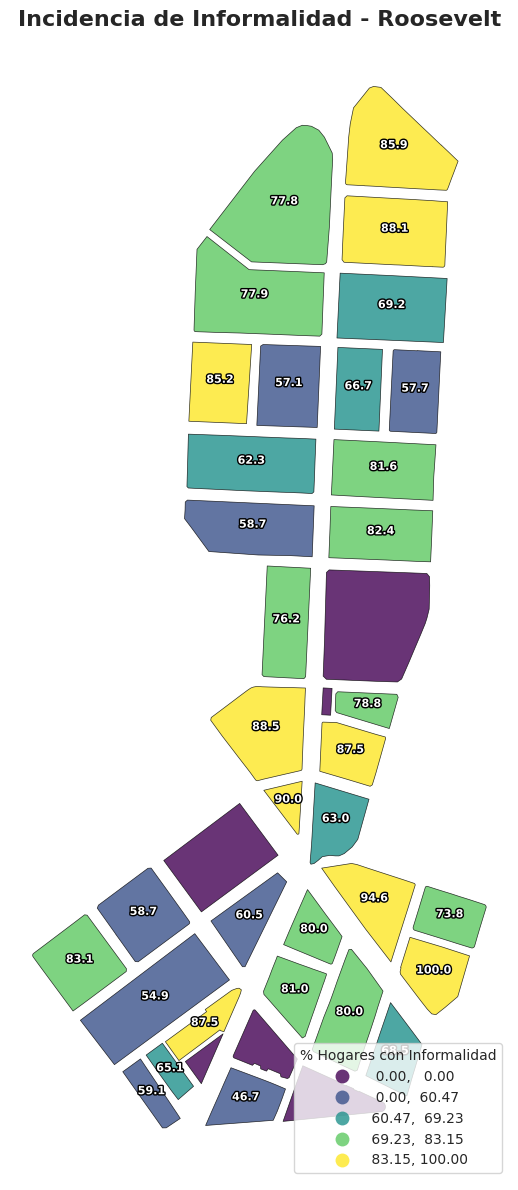

/tmp/ipykernel_1962/2033113690.py:20: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  for x, y, label in zip(gdf.geometry.centroid.x, gdf.geometry.centroid.y, gdf[column]):


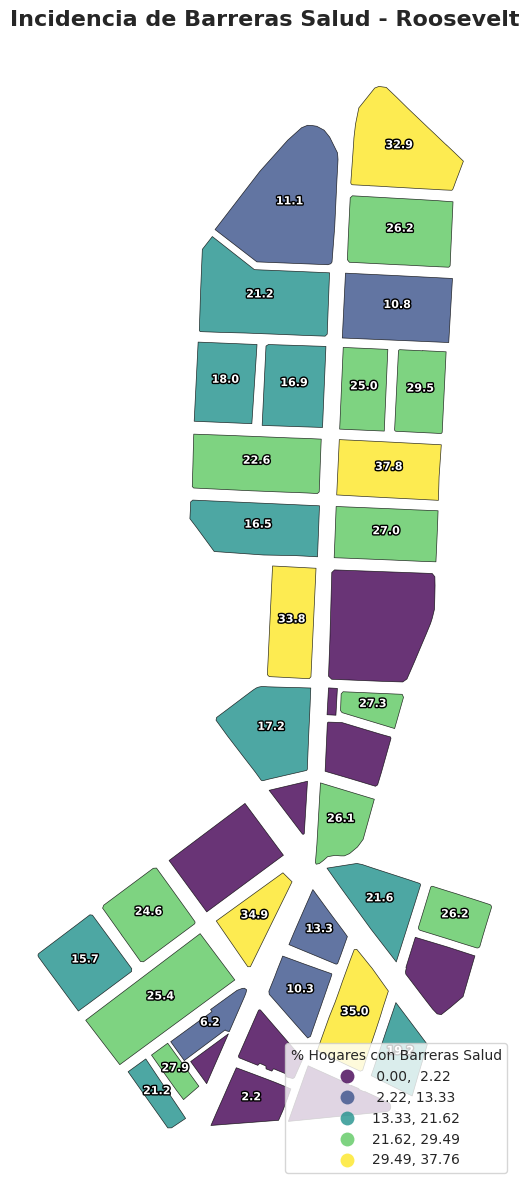

/tmp/ipykernel_1962/2033113690.py:20: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  for x, y, label in zip(gdf.geometry.centroid.x, gdf.geometry.centroid.y, gdf[column]):


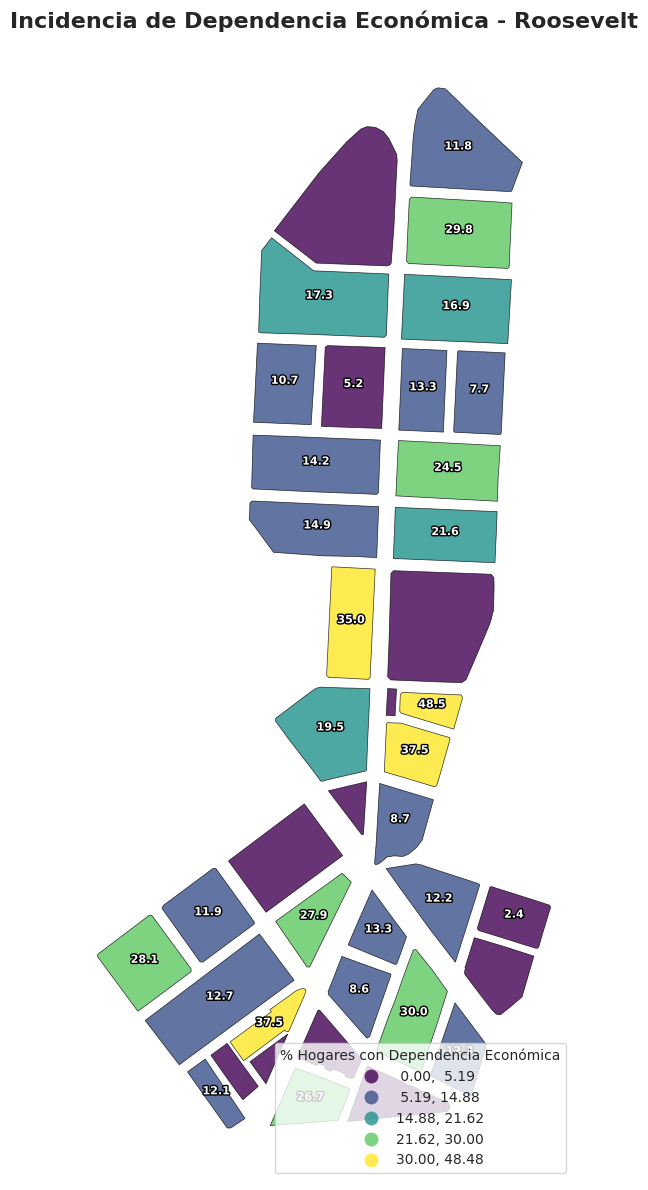

/tmp/ipykernel_1962/2033113690.py:20: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  for x, y, label in zip(gdf.geometry.centroid.x, gdf.geometry.centroid.y, gdf[column]):


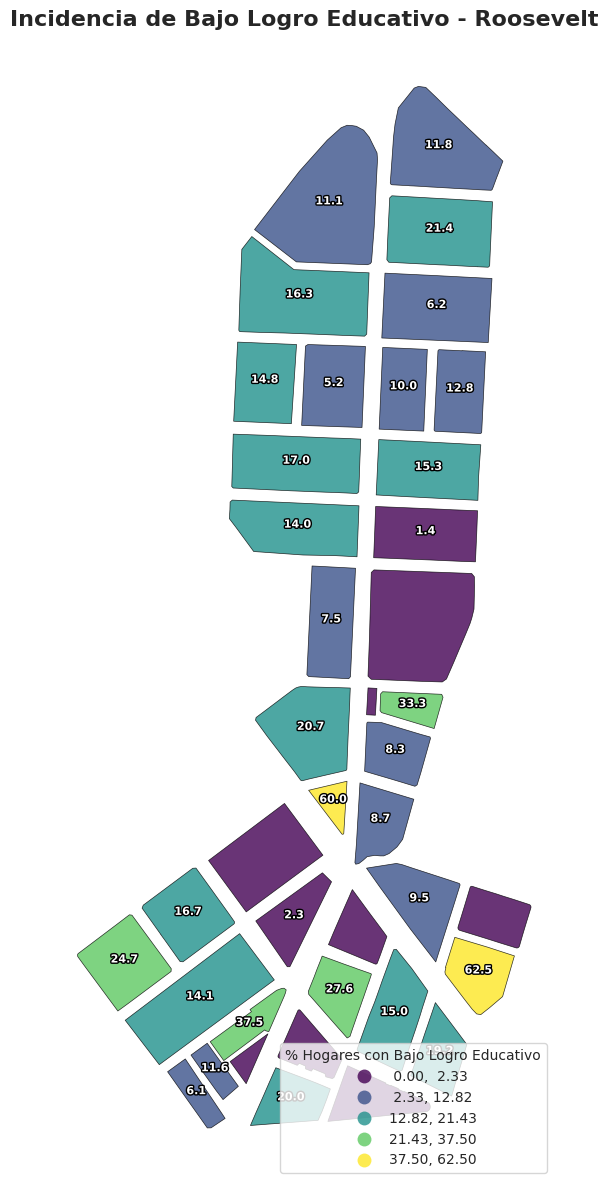

/tmp/ipykernel_1962/2033113690.py:20: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  for x, y, label in zip(gdf.geometry.centroid.x, gdf.geometry.centroid.y, gdf[column]):


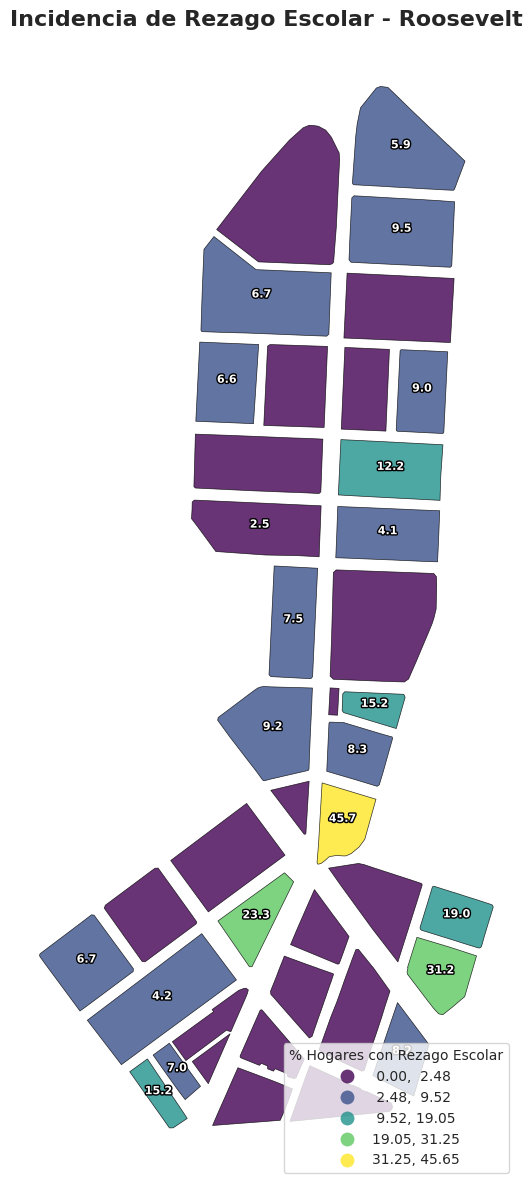

In [21]:
# 5. Generar los 5 mapas prioritarios
for var in top_5:
    plot_ipm_variable(gdf, var, diccionario_nombres[var])